In [2]:
# load packages
import numpy as np 
import scipy.io
from scipy.io   import  loadmat
import pandas as pd
import os
import matplotlib.pyplot as plt #import matplotlib as plt
from scipy.optimize import curve_fit 
import seaborn as sns #import mat73
import pickle as pkl
from datetime import datetime
from itertools import chain
from scipy.io import savemat

In [3]:
from pathlib import Path
MainDir = Path.home() / "Desktop" / "Visual Plasticty Pipeline" / "EEG RCA"

In [ ]:
# change to the directory
os.chdir(MainDir)  
d = os.listdir(MainDir)  # list files in dir

print(f'Available Files to choose from: {len(d)}')
print(f'Files on hand: {d}')

##############################################
# pick files safely
FileN_f1 = d[1]   # or adjust index if you want another file
FileN_f2 = d[0]   # same here

# make full paths
file_path1 = os.path.join(MainDir, FileN_f1)
file_path2 = os.path.join(MainDir, FileN_f2)

# check file 1
print(f'\nFile #1: {file_path1}')
print('Does File #1 Exist?', os.path.exists(file_path1))

# check file 2
print(f'\nFile #2: {file_path2}')
print('Does File #2 Exist?', os.path.exists(file_path2))


Available Files to choose from: 2
Files on hand: ['rcaResults_Sweep_ContrastSweeps_RightHemiF_F2.mat', 'rcaResults_Sweep_ContrastSweeps_LeftHemiF_F1.mat']

File #1: /Users/patricia.naomi/Desktop/Visual Plasticty Pipeline/EEG RCA/rcaResults_Sweep_ContrastSweeps_LeftHemiF_F1.mat
Does File #1 Exist? True

File #2: /Users/patricia.naomi/Desktop/Visual Plasticty Pipeline/EEG RCA/rcaResults_Sweep_ContrastSweeps_RightHemiF_F2.mat
Does File #2 Exist? True


In [79]:
NumBins = 6

In [80]:
# import rca signal data | F1 data and F2 data
df_f1 = scipy.io.loadmat(file_path1) # RCA F1 File
df_f2 = scipy.io.loadmat(file_path2)# RCA F2 File

print(f'Number of Keys in loaded dict: {int(len(df_f1))}')

Number of Keys in loaded dict: 4


In [81]:
print(df_f1.keys())

dict_keys(['__header__', '__version__', '__globals__', 'rcaResult'])


In [82]:
# sort data imported above
rca_f1 = df_f1['rcaResult']['projectedData'][0,0]
f1 = [rca_f1[x,0] for x in range(rca_f1.shape[0])] # entry per subject

rca_f2 = df_f2['rcaResult']['projectedData'][0,0]
f2 = [rca_f2[x,0] for x in range(rca_f2.shape[0])]

print(len(rca_f1))
SignalFiles = [f1, f2] # Hemifield data

65


In [83]:
print(SignalFiles[0][3].shape) 
print('Number of features, number of compnents, number of trials')

(48, 3, 78)
Number of features, number of compnents, number of trials


In [84]:
# load subject names ...
SubNames = df_f1['rcaResult'][0,0][5]
FileName = [x[0][3:] for subjlist in SubNames for x in subjlist[0][2][0]] # rm 'nl-'
print(len(FileName))
UniformFileNames = [str(s).replace('-', '_') for s in FileName]
print(UniformFileNames)
print(len(UniformFileNames))

65
['2651_attnL_20231003_1500', '2651_attnR_20231006_0933', '2652_attnL_20231003_1635', '2652_attnR_20231011_1328', '2653_attnL_20231009_1015', '2653_attnR_20231013_0932', '2654_attnL_20231009_1131', '2654_attnR_20231016_1152', '2655_attnL_20231009_1303', '2655_attnR_20231016_0948', '2657_attnL_20231013_1508', '2657_attnR_20231020_1201', '2658_attnL_20231013_1639', '2658_attnR_20231020_1052', '2659_attnL_20231017_0940', '2659_attnR_20231018_1523', '2660_attnL_20231017_1102', '2661_attnL_20231018_1322', '2661_attnR_20231017_1358', '2663_attnR2_20231030_1659', '2663_attnR_20231019_1018', '2664_attnL_20231020_1452', '2664_attnR_20231019_1145', '2665_attnL_20231024_1329', '2665_attnR_20231019_1512', '2666_attnL_20231023_1612', '2666_attnR_20231019_1643', '2667_attnL_20231025_1522', '2667_attnR_20231023_0947', '2668_attnL_20231027_1251', '2668_attnR_20231023_1058', '2669_attnR_20231023_1241', '2669_attnL_20231024_1432', '2670_attnR_20231024_0941', '2670_attnL_20231201_1521', '2672_attnL_202

In [85]:
# fix a file name 
print('Before and after file name fix')
print(UniformFileNames[-1])
fixName = '345216_attnL_20230929_1732'
UniformFileNames[-1] = fixName
print(UniformFileNames[-1])

Before and after file name fix
345216attnL_20230929_1732
345216_attnL_20230929_1732


In [86]:
NumFiles = int(len(FileName))
print(f'Number of Files to Sort: {NumFiles}')

Number of Files to Sort: 65


In [87]:
File_Split_CatchString = '_'
SubjectNum_Array = [x.split(File_Split_CatchString)[0] for x in UniformFileNames]
print(SubjectNum_Array)
SubjExpCo = [x.split(File_Split_CatchString)[2] for x in UniformFileNames]
print(SubjExpCo)
AttentionCond = [x.split(File_Split_CatchString)[1] for x in UniformFileNames] # 3 was 2 
print(AttentionCond)
print(np.unique(AttentionCond))

['2651', '2651', '2652', '2652', '2653', '2653', '2654', '2654', '2655', '2655', '2657', '2657', '2658', '2658', '2659', '2659', '2660', '2661', '2661', '2663', '2663', '2664', '2664', '2665', '2665', '2666', '2666', '2667', '2667', '2668', '2668', '2669', '2669', '2670', '2670', '2672', '2672', '2674', '2674', '2676', '2677', '2677', '2678', '2695', '2695', '2696', '2696', '2697', '2697', '2708', '2715', '2716', '2726', '2727', '2728', '2728', '2733', '2734', '2737', '345202', '345202', '345215', '345215', '345216', '345216']
['20231003', '20231006', '20231003', '20231011', '20231009', '20231013', '20231009', '20231016', '20231009', '20231016', '20231013', '20231020', '20231013', '20231020', '20231017', '20231018', '20231017', '20231018', '20231017', '20231030', '20231019', '20231020', '20231019', '20231024', '20231019', '20231023', '20231019', '20231025', '20231023', '20231027', '20231023', '20231023', '20231024', '20231024', '20231201', '20231030', '20231025', '20231026', '20231031'

In [88]:
Subject_Identity  = np.unique(SubjectNum_Array)
print((Subject_Identity))

['2651' '2652' '2653' '2654' '2655' '2657' '2658' '2659' '2660' '2661'
 '2663' '2664' '2665' '2666' '2667' '2668' '2669' '2670' '2672' '2674'
 '2676' '2677' '2678' '2695' '2696' '2697' '2708' '2715' '2716' '2726'
 '2727' '2728' '2733' '2734' '2737' '345202' '345215' '345216']


In [89]:
AttentionCond = [x.split(File_Split_CatchString)[1] for x in UniformFileNames] # 3 was 2 
print(AttentionCond)
AttnBool = np.zeros((int(NumFiles)))

for label in range(NumFiles):
    # print(label)
    label_in = AttentionCond[label]
    # print(label_in)

    if label_in == 'attnL':
        AttnBool[label] = 1

AttnBool = AttnBool.astype(int)

print(AttnBool) # 0 == Right, 1 == Left
print(np.unique(AttnBool, return_counts = True)) # 0 == Right, 1 == Left

['attnL', 'attnR', 'attnL', 'attnR', 'attnL', 'attnR', 'attnL', 'attnR', 'attnL', 'attnR', 'attnL', 'attnR', 'attnL', 'attnR', 'attnL', 'attnR', 'attnL', 'attnL', 'attnR', 'attnR2', 'attnR', 'attnL', 'attnR', 'attnL', 'attnR', 'attnL', 'attnR', 'attnL', 'attnR', 'attnL', 'attnR', 'attnR', 'attnL', 'attnR', 'attnL', 'attnL', 'attnR', 'attnL', 'attnR', 'attnR', 'attnL', 'attnR', 'attnR', 'attnL', 'attnR', 'attnR', 'attnL', 'attnL', 'attnR', 'attnL', 'attnL', 'attnL', 'attnR', 'attnL', 'attnL', 'attnR', 'attnL', 'attnL', 'attnL', 'attnL', 'attnR', 'attnL', 'attnR', 'attnR', 'attnL']
[1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 1 0 0 0 1 0 1 0 1 0 1 0 1 0 0 1 0 1 1 0
 1 0 0 1 0 0 1 0 0 1 1 0 1 1 1 0 1 1 0 1 1 1 1 0 1 0 0 1]
(array([0, 1]), array([31, 34]))


In [90]:
AllSubject_IDs, SessionsCompleted = np.unique(np.array(SubjectNum_Array), return_counts = True)
print(f'all participants: {len(AllSubject_IDs)}')
print(AllSubject_IDs, SessionsCompleted)

Subj_WhoCompleted2Sessions  = np.sum(SessionsCompleted == 2)
print(Subj_WhoCompleted2Sessions)

all participants: 38
['2651' '2652' '2653' '2654' '2655' '2657' '2658' '2659' '2660' '2661'
 '2663' '2664' '2665' '2666' '2667' '2668' '2669' '2670' '2672' '2674'
 '2676' '2677' '2678' '2695' '2696' '2697' '2708' '2715' '2716' '2726'
 '2727' '2728' '2733' '2734' '2737' '345202' '345215' '345216'] [2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 1 2 1 2 2 2 1 1 1 1 1 2 1 1 1 2 2
 2]
27


In [91]:
'get unique id numbers to call data >;D'
NumSubs = int(len(np.unique(SubjectNum_Array)))
SubjId, counts = np.unique(SubjectNum_Array, return_counts= True)
print(SubjId)
SubjBool = np.zeros((NumFiles))
for i in range(NumSubs): # NumSubs
    sID = str(SubjId[i]) # a number in array
    #print([x for x in SubjectNum_Array if x == sID])
    indicies = np.where(np.array(SubjectNum_Array) == sID)[0]
    # print(indicies)
    SubjBool[indicies] = int(i)

SubjBool = SubjBool.astype(int)

# SessInds = np.array([int(item[1:]) for item in SubjExpCo]) # session array per subj :)

print(SubjBool) # unique subject names based on occurance

['2651' '2652' '2653' '2654' '2655' '2657' '2658' '2659' '2660' '2661'
 '2663' '2664' '2665' '2666' '2667' '2668' '2669' '2670' '2672' '2674'
 '2676' '2677' '2678' '2695' '2696' '2697' '2708' '2715' '2716' '2726'
 '2727' '2728' '2733' '2734' '2737' '345202' '345215' '345216']
[ 0  0  1  1  2  2  3  3  4  4  5  5  6  6  7  7  8  9  9 10 10 11 11 12
 12 13 13 14 14 15 15 16 16 17 17 18 18 19 19 20 21 21 22 23 23 24 24 25
 25 26 27 28 29 30 31 31 32 33 34 35 35 36 36 37 37]


In [92]:
# Get the unique numbers and counts of occurrences
unique_vals, counts = np.unique(SubjBool, return_counts=True)

# Generate the desired output
NumFilePerSubj = np.concatenate([np.arange(1, count + 1) for count in counts])
print(NumFilePerSubj)
print((np.unique(NumFilePerSubj, return_counts = True)))

[1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2
 1 2 1 1 2 1 1 2 1 2 1 2 1 1 1 1 1 1 2 1 1 1 1 2 1 2 1 2]
(array([1, 2]), array([38, 27]))


#### **Segment Raw Data into ssVEP sweep responses by TimeBlocks + Apply Root Mean Square to Data Mat**

In [93]:
def Sort_RCA_Raw(data, timeBlocks, rca_comp, NumSkipTrials):
    """
    Processes RCA data by cleaning, segmenting, averaging, and computing magnitude response.

    Parameters:
    - data: 3D numpy array [freqs x rca_components x trials]
    - timeBlocks: Number of segments to divide trials into
    - rca_comp: Index of RCA component to use
    - NumSkipTrials: Number of trials to skip per block (for adaptation removal)
    - NumBins: Number of frequency bins used to check for signal rejection

    Returns:
    - processed_mat: 2D numpy array [timeBlocks x features], average response per harmonic
    """

    if not isinstance(data, np.ndarray):
        raise ValueError("Input 'data' must be a numpy array.")

    if data.ndim != 3:
        raise ValueError("Input 'data' must be a 3D array: [freqs x components x trials].")

    data = data.copy()
    data[data == 0] = np.nan

    freqs, _, total_trials = data.shape
    fx_bound_inds = freqs // 2

    if total_trials % timeBlocks != 0:
        raise ValueError("Cannot evenly divide trials into requested timeBlocks. Check input.")

    tx_inds = total_trials // timeBlocks
    processed_mat = np.zeros((timeBlocks, fx_bound_inds))

    for ti in range(timeBlocks):
        print(f'Importing timeBlock # {ti + 1} of {timeBlocks}')

        s = tx_inds * ti + NumSkipTrials
        e = tx_inds * (ti + 1)

        if s >= e or e > total_trials:
            raise IndexError(f"Trial indexing out of bounds: start={s}, end={e}, total={total_trials}")

        Blockx = data[:, rca_comp, s:e]  # [freqs x trials]

        if Blockx.shape[1] == 0:
            raise ValueError(f"Block {ti+1} has no valid trials after skipping.")

        nan_count = np.isnan(Blockx[:NumBins, :]).sum(axis=0)
        Cols2replace = nan_count >= (NumBins * 0.5)
        Blockx[:, Cols2replace] = np.nan

        avgTrialVals = np.nanmean(Blockx, axis=1)

        if np.isnan(avgTrialVals).any():
            print(f"Warning: NaNs present in averaged trial values for block {ti+1}.")

        real_part = avgTrialVals[:fx_bound_inds]
        imag_part = avgTrialVals[fx_bound_inds:]

        Frequency_ValResponses = np.hypot(real_part, imag_part)
        processed_mat[ti, :] = Frequency_ValResponses

    return processed_mat
########################################################################
def Init_RMS(NumBins, cleanFeature_Data, minHarm, maxHarm):
    """
    Root Mean Square Analysis.

    Parameters:
    - NumBins: Number of bins per block
    - cleanFeature_Data: 2D numpy array [blocks x features], flattened harmonic-bin matrix
    - minHarm: Minimum harmonic index (inclusive)
    - maxHarm: Maximum harmonic index (inclusive)

    Returns:
    - rmsProcessed: 2D numpy array [blocks x NumBins], RMS values
    """
    if not isinstance(cleanFeature_Data, np.ndarray):
        raise ValueError("Input must be a numpy array.")

    if cleanFeature_Data.ndim != 2:
        raise ValueError("cleanFeature_Data must be a 2D array.")

    numBlocks = cleanFeature_Data.shape[0]
    rmsProcessed = np.zeros((numBlocks, NumBins))

    for t in range(numBlocks):
        feat = cleanFeature_Data[t].reshape(-1, NumBins)[minHarm:maxHarm+1]
        rmsProcessed[t] = np.sqrt(np.mean(np.square(feat), axis=0))

    return rmsProcessed
######################################################################
def Init_HarmonicIsolation(NumBins, cleanFeature_Data, PickHarmInt):
    """
    Extracts the response for a specific harmonic across time blocks.

    Parameters:
    - NumBins: Number of bins per block
    - cleanFeature_Data: 2D numpy array [blocks x features], flattened harmonic-bin matrix
    - PickHarmInt: Index of harmonic to isolate

    Returns:
    - isoProcessed: 2D numpy array [blocks x NumBins], values for selected harmonic
    """
    if not isinstance(cleanFeature_Data, np.ndarray):
        raise ValueError("Input must be a numpy array.")

    if cleanFeature_Data.ndim != 2:
        raise ValueError("cleanFeature_Data must be a 2D array.")

    numBlocks = cleanFeature_Data.shape[0]
    isoProcessed = np.zeros((numBlocks, NumBins))

    for t in range(numBlocks):
        isoProcessed[t] = cleanFeature_Data[t].reshape(-1, NumBins)[PickHarmInt]

    return isoProcessed


In [94]:
# udims = SignalFiles[0][34].shape[2]
# #print(udims)

# test = Sort_RCA_Raw(data = SignalFiles[0][34], timeBlocks = int(udims), rca_comp = 0, NumSkipTrials = 0)
# print(test.shape)

Importing timeBlock # 1 of 2
Importing timeBlock # 2 of 2
Importing timeBlock # 1 of 2
Importing timeBlock # 2 of 2
(2, 24)


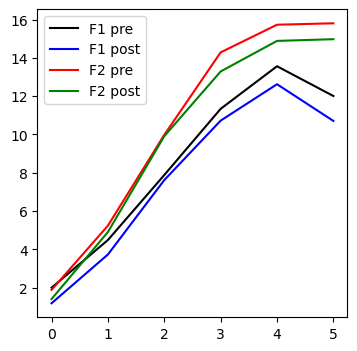

In [95]:
examp_File = 1
fig,axs = plt.subplots(figsize = (4,4))
# test run of functions before mass iteration
cleanData_F1 = Sort_RCA_Raw(data = SignalFiles[0][examp_File], timeBlocks = 2, rca_comp = 0, NumSkipTrials = 0)
cleanData_F2 = Sort_RCA_Raw(data = SignalFiles[1][examp_File], timeBlocks = 2, rca_comp = 0, NumSkipTrials = 0)

print(cleanData_F2.shape)

plt.plot(cleanData_F1[0,0:6], label = 'F1 pre', color = 'black')
plt.plot(cleanData_F1[1,0:6], label = 'F1 post',color = 'blue')
plt.plot(cleanData_F2[0,0:6], label = 'F2 pre', color = 'red')
plt.plot(cleanData_F2[1,0:6], label = 'F2 post',color = 'green')
plt.legend()

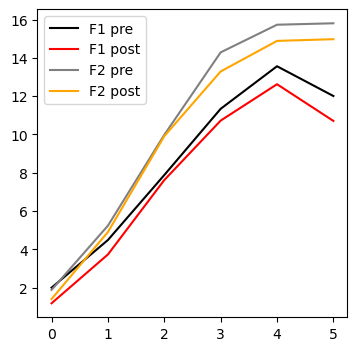

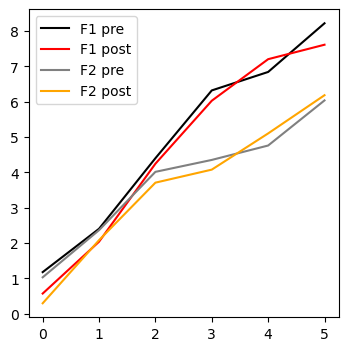

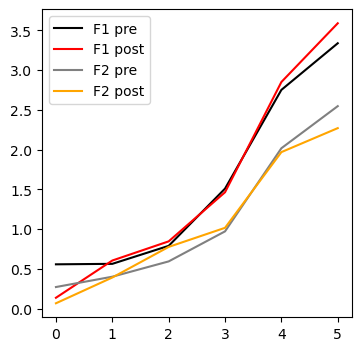

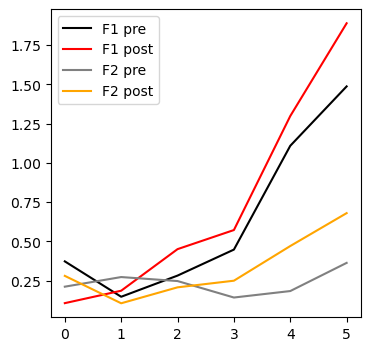

In [96]:
for XHX in range(4):
        fig,axs = plt.subplots(figsize = (4,4))
        rms_LH = Init_HarmonicIsolation(NumBins,cleanFeature_Data = cleanData_F1, PickHarmInt=XHX)
        rms_RH = Init_HarmonicIsolation(NumBins,cleanFeature_Data = cleanData_F2, PickHarmInt= XHX)


        plt.plot(rms_LH[0,:], label = 'F1 pre', color = 'black')
        plt.plot(rms_LH[1,:], label = 'F1 post', color = 'red')

        plt.plot(rms_RH[0,:], label = 'F2 pre', color = 'gray')
        plt.plot(rms_RH[1,:], label = 'F2 post', color = 'orange')

        plt.legend()
        plt.show()

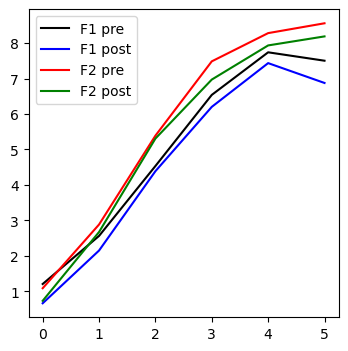

In [97]:
# Visualize RMS data 
fig,axs = plt.subplots(figsize = (4,4))

rms_LH = Init_RMS(NumBins,cleanFeature_Data = cleanData_F1,minHarm = 0,maxHarm = 4)
rms_RH = Init_RMS(NumBins,cleanFeature_Data = cleanData_F2,minHarm = 0,maxHarm = 4)


plt.plot(rms_LH[0,:], label = 'F1 pre', color = 'black')
plt.plot(rms_LH[1,:], label = 'F1 post', color = 'blue')

plt.plot(rms_RH[0,:], label = 'F2 pre', color = 'red')
plt.plot(rms_RH[1,:], label = 'F2 post', color = 'green')

plt.legend()

#### **If everything looks right, perform pipeline for all data files**

In [98]:
print(len(SignalFiles[0]))
print(len(SignalFiles[1]))

65
65


In [99]:
# Run mass iteration of data timeBlock sorting if everything seems good :)
RCA_F1 = {}
RCA_F2 = {}

for nFs1 in range(NumFiles): # NumFiles
    print(nFs1)
    dataMat1 = SignalFiles[0][nFs1] # import a single data file : [features x components x trials]
    print(dataMat1.shape)
    featureData1 = Sort_RCA_Raw(dataMat1, timeBlocks = 2, rca_comp = 0,NumSkipTrials = 0) # = output = [timeBlocks x features]
    RCA_F1[f'featureData_{nFs1}'] = featureData1 # timeblocks x numfeatures
    # print(featureData1.shape)

for nFs2 in range(NumFiles):
    print(nFs2)
    dataMat2 = SignalFiles[1][nFs2] # import a single data file : [features x components x trials]
    print(dataMat2.shape)
    featureData2 = Sort_RCA_Raw(dataMat2, timeBlocks = 2, rca_comp = 0, NumSkipTrials = 0) # = output = [timeBlocks x features]
    RCA_F2[f'featureData_{nFs2}'] = featureData2
    

0
(48, 3, 78)
Importing timeBlock # 1 of 2
Importing timeBlock # 2 of 2
1
(48, 3, 78)
Importing timeBlock # 1 of 2
Importing timeBlock # 2 of 2
2
(48, 3, 78)
Importing timeBlock # 1 of 2
Importing timeBlock # 2 of 2
3
(48, 3, 78)
Importing timeBlock # 1 of 2
Importing timeBlock # 2 of 2
4
(48, 3, 78)
Importing timeBlock # 1 of 2
Importing timeBlock # 2 of 2
5
(48, 3, 78)
Importing timeBlock # 1 of 2
Importing timeBlock # 2 of 2
6
(48, 3, 78)
Importing timeBlock # 1 of 2
Importing timeBlock # 2 of 2
7
(48, 3, 78)
Importing timeBlock # 1 of 2
Importing timeBlock # 2 of 2
8
(48, 3, 78)
Importing timeBlock # 1 of 2
Importing timeBlock # 2 of 2
9
(48, 3, 78)
Importing timeBlock # 1 of 2
Importing timeBlock # 2 of 2
10
(48, 3, 78)
Importing timeBlock # 1 of 2
Importing timeBlock # 2 of 2
11
(48, 3, 78)
Importing timeBlock # 1 of 2
Importing timeBlock # 2 of 2
12
(48, 3, 78)
Importing timeBlock # 1 of 2
Importing timeBlock # 2 of 2
13
(48, 3, 78)
Importing timeBlock # 1 of 2
Importing timeBlo

### **Perform Harmonic Isolation For all Data - Export 2F - 8F Responses in a single File**

In [100]:
TwoF1 = {}
TwoF2 = {}


for NF in range(NumFiles):
    featureMatImport_1 = RCA_F1[f'featureData_{NF}'] # [timeBlocks x features]
    TwoF1[f'Data_{NF}'] = Init_HarmonicIsolation(NumBins,cleanFeature_Data = featureMatImport_1, PickHarmInt = 0)

    featureMatImport_2 = RCA_F2[f'featureData_{NF}'] # [timeBlocks x features]
    TwoF2[f'Data_{NF}'] = Init_HarmonicIsolation(NumBins,cleanFeature_Data = featureMatImport_2,PickHarmInt = 0)

In [101]:
FourF1 = {}
FourF2 = {}


for NF in range(NumFiles):
    featureMatImport_1 = RCA_F1[f'featureData_{NF}'] # [timeBlocks x features]
    FourF1[f'Data_{NF}'] = Init_HarmonicIsolation(NumBins,cleanFeature_Data = featureMatImport_1, PickHarmInt = 1)

    featureMatImport_2 = RCA_F2[f'featureData_{NF}'] # [timeBlocks x features]
    FourF2[f'Data_{NF}'] = Init_HarmonicIsolation(NumBins,cleanFeature_Data = featureMatImport_2,PickHarmInt = 1)

In [102]:
SixF1 = {}
SixF2 = {}


for NF in range(NumFiles):
    featureMatImport_1 = RCA_F1[f'featureData_{NF}'] # [timeBlocks x features]
    SixF1[f'Data_{NF}'] = Init_HarmonicIsolation(NumBins,cleanFeature_Data = featureMatImport_1, PickHarmInt = 2)

    featureMatImport_2 = RCA_F2[f'featureData_{NF}'] # [timeBlocks x features]
    SixF2[f'Data_{NF}'] = Init_HarmonicIsolation(NumBins,cleanFeature_Data = featureMatImport_2,PickHarmInt = 2)

In [103]:
EightF1 = {}
EightF2 = {}

for NF in range(NumFiles):
    featureMatImport_1 = RCA_F1[f'featureData_{NF}'] # [timeBlocks x features]
    EightF1[f'Data_{NF}'] = Init_HarmonicIsolation(NumBins,cleanFeature_Data = featureMatImport_1, PickHarmInt = 3)

    featureMatImport_2 = RCA_F2[f'featureData_{NF}'] # [timeBlocks x features]
    EightF2[f'Data_{NF}'] = Init_HarmonicIsolation(NumBins,cleanFeature_Data = featureMatImport_2,PickHarmInt = 3)

#### **Now Compute the RMS for Each EEG File :)**

In [104]:
# Run mass iteration of RMS data timeBlock sorting if everything seems good :)
RootMeanSq_F1 = {}
RootMeanSq_F2 = {}

for rms_1 in range(NumFiles):
    # print(rms_1)
    featureMatImport_1 = RCA_F1[f'featureData_{rms_1}'] # [timeBlocks x features]
    RootMeanSq_F1[f'RMS_Data_{rms_1}'] = Init_RMS(NumBins,cleanFeature_Data = featureMatImport_1,minHarm = 0,maxHarm = 4)

    #print(RootMeanSq_F1[f'RMS_Data_{rms_1}'])

    featureMatImport_2 = RCA_F2[f'featureData_{rms_1}'] # [timeBlocks x features]
    RootMeanSq_F2[f'RMS_Data_{rms_1}'] = Init_RMS(NumBins,cleanFeature_Data = featureMatImport_2,minHarm = 0,maxHarm = 4)

### **Data Format | Single Dict Key = [timeBlock x Bins]**

In [105]:
def MakeNewFolder(folder_name):
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)
        print(f'Folder {folder_name} created')
    else:
        print(f'Folder {folder_name} already exists')

In [106]:
DataDirOut = Path.home() / "Desktop" / "Visual Plasticty Pipeline" / "Outputs"
os.chdir(DataDirOut)

folder_name = 'PrePostProcessed'
MakeNewFolder(folder_name)

os.chdir(folder_name)


Folder PrePostProcessed already exists


#### **Combine all Hemifield responses into a single data matrix**

In [107]:
TwoF1_All = np.stack(list(TwoF1.values()), axis=0)
TwoF2_All = np.stack(list(TwoF2.values()), axis=0)

In [108]:
FourF1_All = np.stack(list(FourF1.values()), axis=0)
FourF2_All = np.stack(list(FourF2.values()), axis=0)

In [109]:
SixF1_All = np.stack(list(SixF1.values()), axis=0)
SixF2_All = np.stack(list(SixF2.values()), axis=0)

In [110]:
EightF1_All = np.stack(list(EightF1.values()), axis=0)
EightF2_All = np.stack(list(EightF2.values()), axis=0)

In [111]:
RootMeanSq_F1_allData =  np.stack(list(RootMeanSq_F1.values()), axis=0)
print(RootMeanSq_F1_allData.shape)

RootMeanSq_F2_allData =  np.stack(list(RootMeanSq_F2.values()), axis=0)
print(RootMeanSq_F2_allData.shape)

print(RootMeanSq_F1_allData)

(65, 2, 6)
(65, 2, 6)
[[[1.04818887 2.46002755 4.17650791 6.02904212 7.26523592 6.86295312]
  [0.71112191 2.08859782 4.17046023 5.80725193 6.93701035 6.40141949]]

 [[1.20771924 2.5633493  4.53396413 6.53903948 7.7395538  7.5026923 ]
  [0.66401883 2.15122709 4.38813503 6.20156033 7.43492426 6.8754626 ]]

 [[0.34077952 0.99793871 1.5322391  1.73605796 1.32868954 1.21565875]
  [1.10421353 1.27111822 1.58681523 1.70541569 0.88499103 1.05640678]]

 [[0.48898906 0.87884945 1.20449973 1.38464871 1.31046738 1.0849407 ]
  [0.38190971 0.84430971 1.16018929 1.2804935  1.07476031 0.85767714]]

 [[0.27157146 0.94453124 1.45632531 1.83816576 1.96889529 2.29449152]
  [0.54030366 0.98720253 1.34793193 1.90478024 2.11206815 2.40467279]]

 [[0.1407538  0.40364554 0.62532091 0.65423747 0.77984798 0.77134805]
  [0.19668332 0.40132436 0.72359459 0.90815411 0.92631521 0.9494236 ]]

 [[0.61094579 1.28275922 1.9105975  2.73569797 2.93326596 2.65427268]
  [0.54747176 1.28353955 2.00646755 2.61527865 2.7324769

In [ ]:
dataOut = {
   'F1_RMS_Data' : RootMeanSq_F1_allData,
    'F2_RMS_Data' : RootMeanSq_F2_allData,
    '2F1' : TwoF1_All,
    '2F2' : TwoF2_All,
    '4F1' : FourF1_All,
    '4F2' : FourF2_All,
    '6F1' : SixF1_All,
    '6F2' : SixF2_All,
    '8F1' : EightF1_All,
    '8F2' : EightF2_All,
    'Files_pSubj'  :SubjBool,# id for subject data [how many files belong to 1 subject]
    'Attn_Condition_pFile': AttnBool, # attentional deplyment per file 
    'TotFiles_pSubj':NumFilePerSubj, # all file in terms of session day per subject
    'Subject_ID_Tag': Subject_Identity # all Subject IDs assigned for this study
    # 'Notes': f'First 5 Trials ommited from sorting'
}

In [ ]:

dnt = datetime.now()
fdnt = dnt.strftime("%Y%m%d_%H%M%S")

File_AddOn_Name = 'contrast_response_functions'  # lowercase + underscores preferred
FileOutName = f'rca_clean_{File_AddOn_Name}_data_study1'
ExportFileName = f'{FileOutName}_full_{fdnt}.mat'

print(ExportFileName)

rca_clean_contrast_response_functions_data_study1_full_20250911_184409.mat


In [114]:
# Export to .mat file
savemat(ExportFileName, dataOut)

print(f"Data has been exported to '{ExportFileName}'.")

Data has been exported to 'rca_clean_contrast_response_functions_data_study1_full_20250911_184409.mat'.
